# Systematic HMM Training and Model Selection

This notebook provides an interactive interface for systematic training and evaluation of HMM models with 2-4 states.

## Objectives
- Load and visualize [s_LDC, s_MR, s_TSMOM] signals
- Train HMM models with 2, 3, and 4 states systematically
- Evaluate models using AIC, BIC, cross-validation, and interpretability metrics
- Analyze regime characteristics and economic interpretations
- Select the best model with visual comparison tools
- Generate production-ready artifacts

## 1. Setup and Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import json
import time
import warnings
warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'py'))

from imp.hmm.trainer import EnhancedHMMTrainer
from imp.hmm.regime_analysis import RegimeAnalyzer
from imp.hmm.models import HMMArtifact
from imp.visualization.regime_visualizer import RegimeVisualizer
from hmmlearn import hmm

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print('✓ All imports successful')
print(f'✓ Project root: {project_root}')

✓ All imports successful
✓ Project root: /home/nipung2010/fictional-enigma


## 2. Load and Visualize Data

In [2]:
# Load processed signals
data_path = project_root / 'notebooks' / 'regime_analysis_results' / 'signals_with_regimes.parquet'
if not data_path.exists():
    data_path = project_root / 'notebooks' / 'processed_data' / 'signals_processed.parquet'

print(f'Loading data from: {data_path}')
df = pd.read_parquet(data_path)

# Check which signal naming convention is used
if 's_LDC' in df.columns:
    required_signals = ['s_LDC', 's_MR', 's_TSMOM']
    signal_names = ['LDC', 'MR', 'TSMOM']
elif 's_signal_1' in df.columns:
    required_signals = ['s_signal_1', 's_signal_2', 's_signal_3']
    signal_names = ['Signal 1', 'Signal 2', 'Signal 3']
else:
    # Try to find any signal columns
    signal_cols = [col for col in df.columns if col.startswith('s_')]
    if len(signal_cols) >= 3:
        required_signals = signal_cols[:3]
        signal_names = [col.replace('s_', '').upper() for col in required_signals]
    else:
        raise ValueError(f'Could not find signal columns. Available columns: {df.columns.tolist()}')

observations = df[required_signals].values
nan_mask = ~np.isnan(observations).any(axis=1)
observations = observations[nan_mask]
df_clean = df[nan_mask].copy()

print(f'\n✓ Loaded {len(observations)} observations')
print(f'✓ Signals: {required_signals}')
print(f'✓ Signal names: {signal_names}')
print(f'\nSignal Statistics:')
print(df_clean[required_signals].describe())

Loading data from: /home/nipung2010/fictional-enigma/notebooks/regime_analysis_results/signals_with_regimes.parquet

✓ Loaded 2000 observations
✓ Signals: ['s_signal_1', 's_signal_2', 's_signal_3']
✓ Signal names: ['Signal 1', 'Signal 2', 'Signal 3']

Signal Statistics:
         s_signal_1    s_signal_2    s_signal_3
count  2.000000e+03  2.000000e+03  2.000000e+03
mean  -1.421085e-17 -2.842171e-17 -5.684342e-17
std    1.000000e+00  1.000000e+00  1.000000e+00
min   -3.083919e+00 -3.119333e+00 -3.089693e+00
25%   -5.650647e-01 -5.700268e-01 -5.360883e-01
50%   -5.247969e-02 -2.921052e-02 -1.629299e-02
75%    6.347889e-01  6.610952e-01  6.402499e-01
max    3.082277e+00  3.046449e+00  2.924374e+00


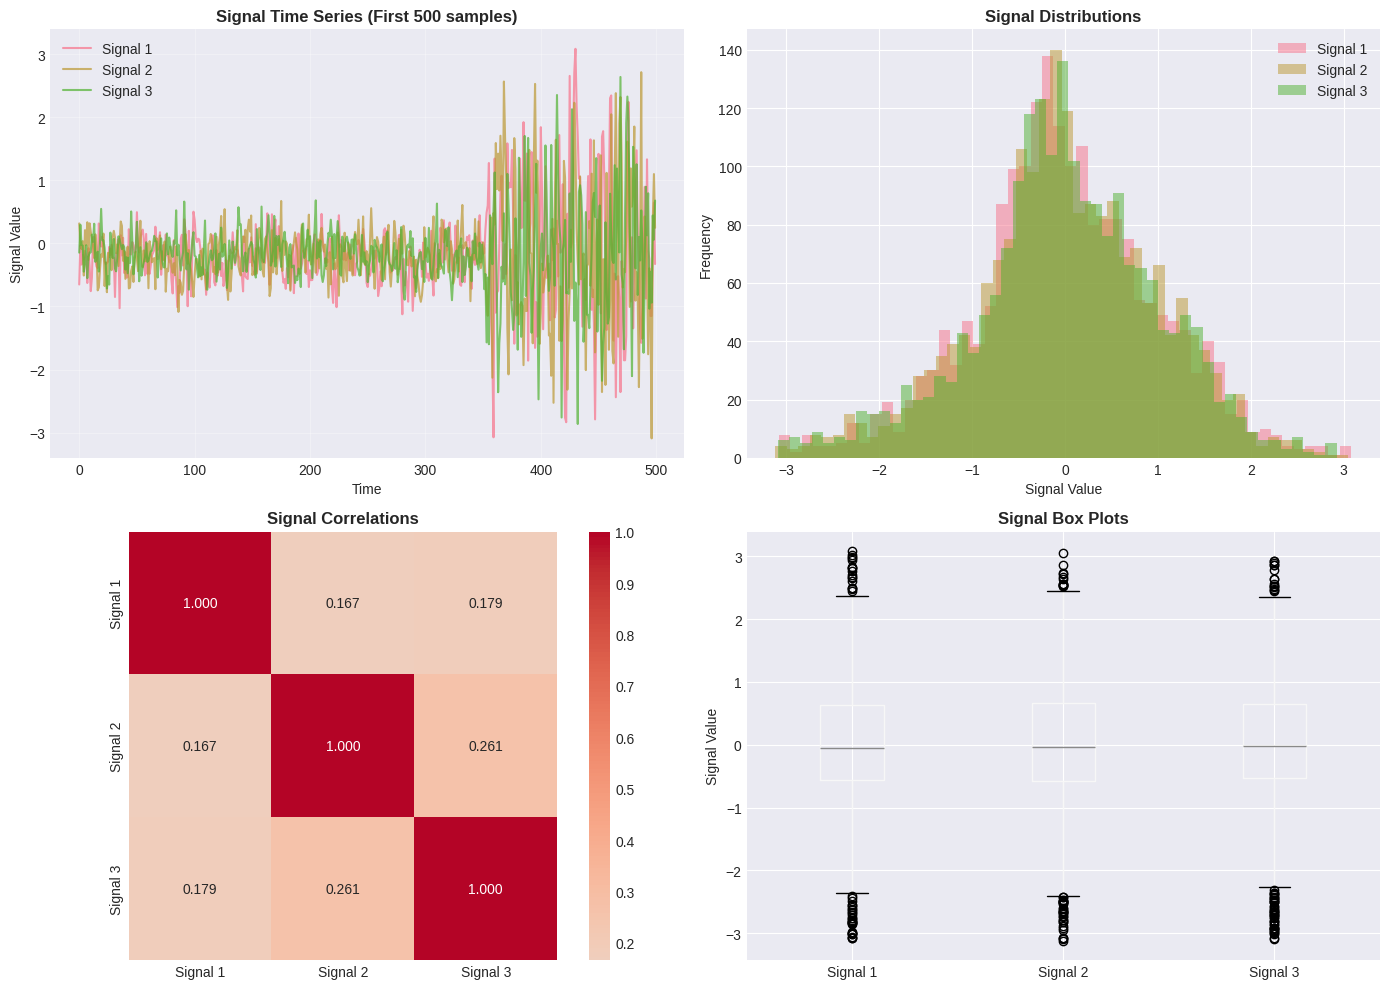

✓ Data visualization complete


In [3]:
# Visualize signals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for idx, signal in enumerate(required_signals):
    ax.plot(df_clean[signal].values[:500], label=signal_names[idx], alpha=0.7)
ax.set_title('Signal Time Series (First 500 samples)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Signal Value')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for idx, signal in enumerate(required_signals):
    ax.hist(df_clean[signal].values, bins=50, alpha=0.5, label=signal_names[idx])
ax.set_title('Signal Distributions', fontsize=12, fontweight='bold')
ax.set_xlabel('Signal Value')
ax.set_ylabel('Frequency')
ax.legend()

ax = axes[1, 0]
corr_matrix = df_clean[required_signals].corr()
# Rename for display
corr_matrix.index = signal_names
corr_matrix.columns = signal_names
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Signal Correlations', fontsize=12, fontweight='bold')

ax = axes[1, 1]
df_plot = df_clean[required_signals].copy()
df_plot.columns = signal_names
df_plot.boxplot(ax=ax)
ax.set_title('Signal Box Plots', fontsize=12, fontweight='bold')
ax.set_ylabel('Signal Value')

plt.tight_layout()
plt.show()

print('✓ Data visualization complete')

## 3. Systematic Training with Progress Tracking

In [4]:
# Configuration
n_states_range = [2, 3, 4]
cv_folds = 5
n_iterations = 100
random_state = 42

training_results = {}
trained_models = {}

print('='*80)
print('SYSTEMATIC HMM TRAINING')
print('='*80)
print(f'\nConfigurations: {n_states_range}')
print(f'CV folds: {cv_folds}')
print(f'Max iterations: {n_iterations}\n')

SYSTEMATIC HMM TRAINING

Configurations: [2, 3, 4]
CV folds: 5
Max iterations: 100



In [5]:
# Train models with live progress updates
for i, n_states in enumerate(n_states_range, 1):
    config_name = f'{n_states}_states'
    print(f'\n{"="*80}')
    print(f'Training {i}/{len(n_states_range)}: {config_name}')
    print(f'{"="*80}')
    
    try:
        trainer = EnhancedHMMTrainer(
            n_states=n_states,
            library='hmmlearn',
            covariance_type='full',
            random_state=random_state
        )
        
        print(f'\n🔄 Running {cv_folds}-fold cross-validation...')
        start_time = time.time()
        cv_results = trainer.cross_validate(observations, cv_folds=cv_folds, n_iterations=n_iterations)
        cv_time = time.time() - start_time
        print(f'  ✓ CV Log-Likelihood: {cv_results.get("log_likelihood_mean", 0):.2f} ± {cv_results.get("log_likelihood_std", 0):.2f}')
        print(f'  ✓ CV Time: {cv_time:.2f}s')
        
        print(f'\n🎯 Training final model...')
        start_time = time.time()
        artifact = trainer.train(observations, n_iterations=n_iterations)
        train_time = time.time() - start_time
        print(f'  ✓ AIC: {artifact.metadata["aic"]:.2f}')
        print(f'  ✓ BIC: {artifact.metadata["bic"]:.2f}')
        print(f'  ✓ Training Time: {train_time:.2f}s')
        
        training_results[config_name] = {
            'artifact': artifact,
            'cv_results': cv_results,
            'n_states': n_states,
            'train_time': train_time,
            'cv_time': cv_time
        }
        trained_models[config_name] = trainer
        print(f'\n✅ {config_name} complete!')
        
    except Exception as e:
        print(f'\n❌ {config_name} failed: {e}')

print(f'\n{"="*80}')
print(f'✅ Training Complete!')
print(f'{"="*80}')


Training 1/3: 2_states

🔄 Running 5-fold cross-validation...
  ✓ CV Log-Likelihood: -2551.89 ± 2195.02
  ✓ CV Time: 0.75s

🎯 Training final model...
  ✓ AIC: 14906.98
  ✓ BIC: 15024.59
  ✓ Training Time: 0.20s

✅ 2_states complete!

Training 2/3: 3_states

🔄 Running 5-fold cross-validation...
  ✓ CV Log-Likelihood: -2622.62 ± 2365.37
  ✓ CV Time: 1.23s

🎯 Training final model...
  ✓ AIC: 15453.68
  ✓ BIC: 15649.71
  ✓ Training Time: 0.41s

✅ 3_states complete!

Training 3/3: 4_states

🔄 Running 5-fold cross-validation...
  ✓ CV Log-Likelihood: -2589.00 ± 2384.39
  ✓ CV Time: 1.33s

🎯 Training final model...
  ✓ AIC: 13595.08
  ✓ BIC: 13880.73
  ✓ Training Time: 0.35s

✅ 4_states complete!

✅ Training Complete!


## 4. Model Comparison with AIC/BIC Charts

In [6]:
# Create comparison DataFrame
comparison_data = []
for config_name, result in training_results.items():
    if 'error' in result:
        continue
    artifact = result['artifact']
    cv_results = result['cv_results']
    comparison_data.append({
        'Configuration': config_name,
        'States': result['n_states'],
        'AIC': artifact.metadata['aic'],
        'BIC': artifact.metadata['bic'],
        'Log-Likelihood': artifact.metadata['convergence_log_likelihood'],
        'CV Log-Likelihood': cv_results.get('log_likelihood_mean', np.nan),
        'CV Std': cv_results.get('log_likelihood_std', np.nan),
        'Train Time (s)': result['train_time']
    })

df_comparison = pd.DataFrame(comparison_data)
print('\n📊 Model Comparison Summary')
print('='*80)
display(df_comparison)


📊 Model Comparison Summary


,Configuration,States,AIC,BIC,Log-Likelihood,CV Log-Likelihood,CV Std,Train Time (s)
0,2_states,2,14906.975473,15024.594425,-7432.487736,-2551.890240,2195.024229,0.196034
1,3_states,3,15453.676540,15649.708126,-7691.838270,-2622.619754,2365.368959,0.414337
2,4_states,4,13595.081578,13880.727603,-6746.540789,-2588.995108,2384.388787,0.352968


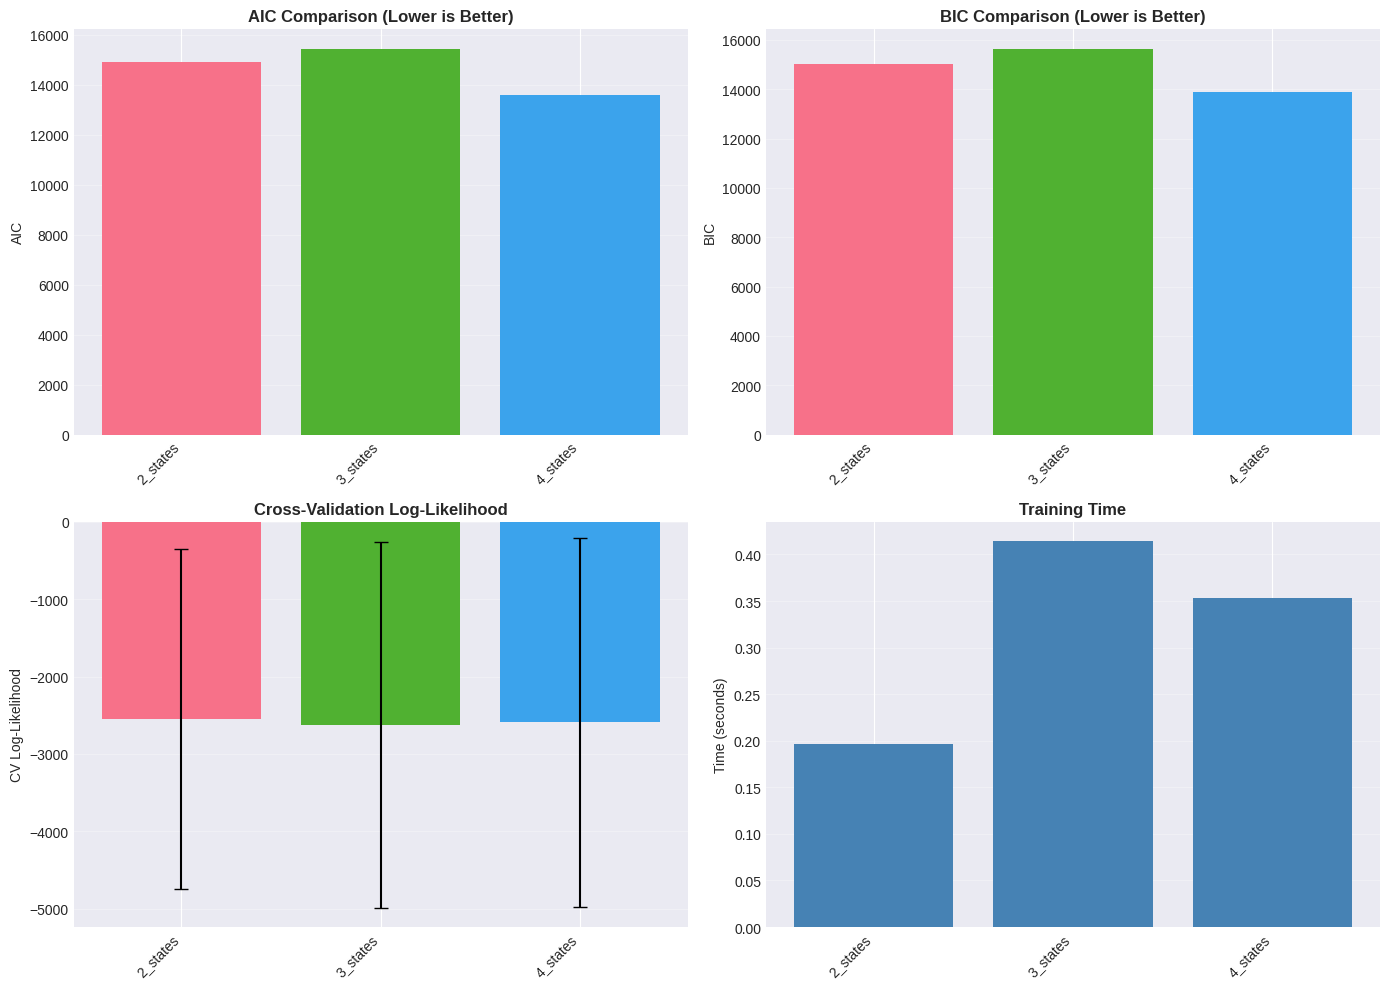

In [7]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.bar(df_comparison['Configuration'], df_comparison['AIC'], color=sns.color_palette('husl', len(df_comparison)))
ax.set_title('AIC Comparison (Lower is Better)', fontsize=12, fontweight='bold')
ax.set_ylabel('AIC')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax = axes[0, 1]
ax.bar(df_comparison['Configuration'], df_comparison['BIC'], color=sns.color_palette('husl', len(df_comparison)))
ax.set_title('BIC Comparison (Lower is Better)', fontsize=12, fontweight='bold')
ax.set_ylabel('BIC')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax = axes[1, 0]
ax.bar(df_comparison['Configuration'], df_comparison['CV Log-Likelihood'], yerr=df_comparison['CV Std'], capsize=5, color=sns.color_palette('husl', len(df_comparison)))
ax.set_title('Cross-Validation Log-Likelihood', fontsize=12, fontweight='bold')
ax.set_ylabel('CV Log-Likelihood')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax = axes[1, 1]
x = np.arange(len(df_comparison))
ax.bar(x, df_comparison['Train Time (s)'], color='steelblue')
ax.set_title('Training Time', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Configuration'])
ax.set_ylabel('Time (seconds)')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Detailed Regime Analysis with Economic Interpretations

In [8]:
# Perform regime analysis
regime_analysis_results = {}
print('\n' + '='*80)
print('REGIME ANALYSIS')
print('='*80)

for config_name, result in training_results.items():
    if 'error' in result:
        continue
    print(f'\n📊 Analyzing {config_name}...')
    artifact = result['artifact']
    
    try:
        analyzer = RegimeAnalyzer(artifact)
        model = hmm.GaussianHMM(n_components=artifact.n_states, covariance_type='full')
        model.transmat_ = np.array(artifact.transition_matrix)
        model.startprob_ = np.array(artifact.initial_probabilities)
        model.means_ = np.array(artifact.means)
        model.covars_ = np.array(artifact.covariances)
        state_sequence = model.predict(observations)
        
        characteristics = analyzer.characterize_regimes(observations, state_sequence)
        persistence = analyzer.analyze_state_persistence(state_sequence)
        interpretations = analyzer.interpret_regimes(characteristics, persistence)
        
        interp_scores = []
        for state_id in characteristics.keys():
            char = characteristics[state_id]
            pers = persistence.get(state_id)
            volatility_score = char.volatility
            persistence_score = min(1.0, pers.mean_duration / 20.0) if pers else 0.0
            interp_scores.append((volatility_score * 0.5 + persistence_score * 0.5))
        interpretability_score = float(np.mean(interp_scores))
        
        regime_analysis_results[config_name] = {
            'state_sequence': state_sequence,
            'characteristics': characteristics,
            'persistence': persistence,
            'interpretations': interpretations,
            'interpretability_score': interpretability_score
        }
        print(f'  ✓ Interpretability Score: {interpretability_score:.3f}')
    except Exception as e:
        print(f'  ❌ Failed: {e}')

print(f'\n✅ Regime analysis complete!')


REGIME ANALYSIS

📊 Analyzing 2_states...
  ✓ Interpretability Score: 0.960

📊 Analyzing 3_states...
  ✓ Interpretability Score: 0.609

📊 Analyzing 4_states...
  ✓ Interpretability Score: 0.717

✅ Regime analysis complete!


In [9]:
# Display regime characteristics
for config_name, analysis in regime_analysis_results.items():
    if 'error' in analysis:
        continue
    print(f'\n{"="*80}')
    print(f'{config_name.upper()} - REGIME CHARACTERISTICS')
    print(f'{"="*80}')
    characteristics = analysis['characteristics']
    persistence = analysis['persistence']
    interpretations = analysis['interpretations']
    for state_id in sorted(characteristics.keys()):
        char = characteristics[state_id]
        pers = persistence.get(state_id)
        interp = interpretations.get(state_id)
        print(f'\n🔹 State {state_id}:')
        print(f'   Volatility: {char.volatility:.4f}')
        # mean_values is a dict, so iterate over it
        for feature_name, mean_val in char.mean_values.items():
            print(f'   Mean {feature_name}: {mean_val:.4f}')
        if pers:
            print(f'   Mean Duration: {pers.mean_duration:.2f} periods')
            print(f'   Median Duration: {pers.median_duration:.2f} periods')
            print(f'   Total Occurrences: {pers.total_occurrences}')
            print(f'   Stable Periods: {pers.stable_periods}')
        if interp:
            print(f'   Interpretation: {interp.regime_type}')
            print(f'   Market Condition: {interp.market_condition}')
            print(f'   Risk Level: {interp.risk_level}')
            print(f'   Trading Recommendation: {interp.trading_recommendation}')
            if interp.key_characteristics:
                print(f'   Key Characteristics: {", ".join(interp.key_characteristics)}')


2_STATES - REGIME CHARACTERISTICS

🔹 State 0:
   Volatility: 0.6820
   Mean s_ldc: 0.2140
   Mean s_mr: 0.2606
   Mean s_tsmom: 0.3140
   Mean Duration: 305.33 periods
   Median Duration: 353.00 periods
   Total Occurrences: 3
   Stable Periods: 3
   Interpretation: High Volatility
   Market Condition: Sideways
   Risk Level: Medium
   Trading Recommendation: Reduce position sizes, increase stop losses; Regime shows persistence - suitable for longer holding periods
   Key Characteristics: High volatility, Strong trending behavior, Strong mean reversion, Highly persistent regime

🔹 State 1:
   Volatility: 1.1578
   Mean s_ldc: -0.1809
   Mean s_mr: -0.2202
   Mean s_tsmom: -0.2654
   Mean Duration: 542.00 periods
   Median Duration: 542.00 periods
   Total Occurrences: 2
   Stable Periods: 2
   Interpretation: High Volatility
   Market Condition: Sideways
   Risk Level: High
   Trading Recommendation: Reduce position sizes, increase stop losses; Implement strict risk controls; Regime s

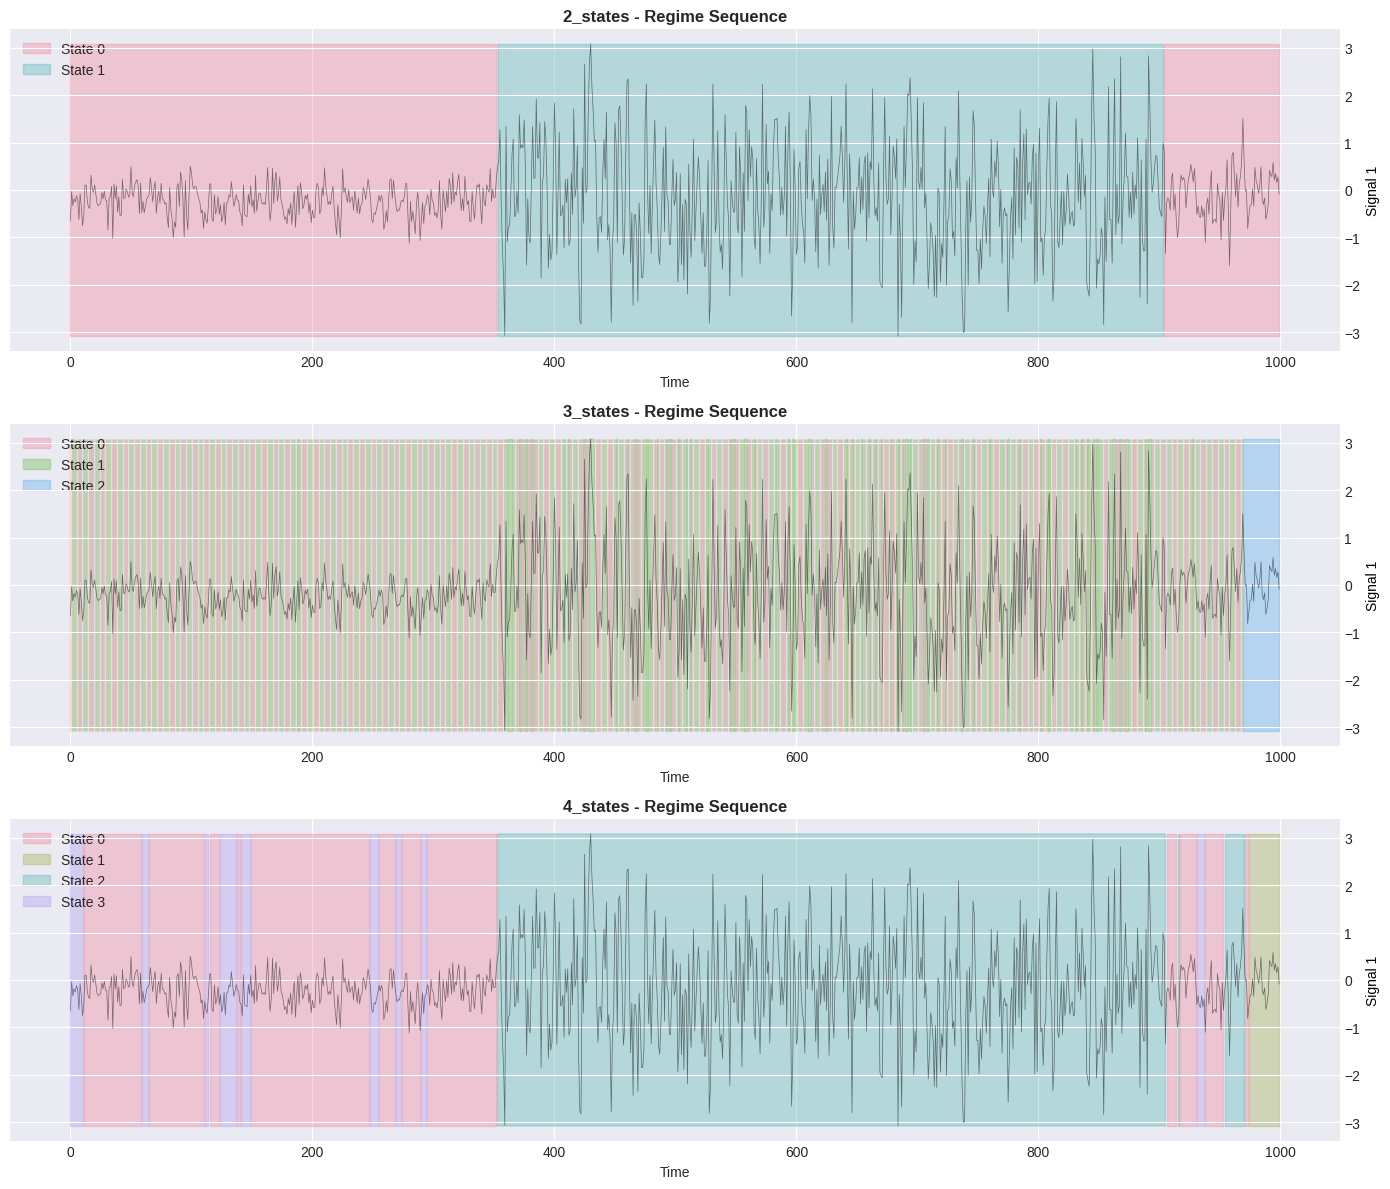

✓ Regime visualization complete


In [10]:
# Visualize regime sequences
n_models = len([r for r in regime_analysis_results.values() if 'error' not in r])
fig, axes = plt.subplots(n_models, 1, figsize=(14, 4*n_models))
if n_models == 1:
    axes = [axes]

plot_idx = 0
sample_range = slice(0, min(1000, len(observations)))
for config_name, analysis in regime_analysis_results.items():
    if 'error' in analysis:
        continue
    ax = axes[plot_idx]
    state_sequence = analysis['state_sequence'][sample_range]
    colors = sns.color_palette('husl', training_results[config_name]['n_states'])
    for state_id in range(training_results[config_name]['n_states']):
        mask = state_sequence == state_id
        ax.fill_between(range(len(state_sequence)), 0, 1, where=mask, alpha=0.3, color=colors[state_id], label=f'State {state_id}')
    ax2 = ax.twinx()
    ax2.plot(observations[sample_range, 0], color='black', alpha=0.5, linewidth=0.5)
    ax2.set_ylabel(signal_names[0], color='black')
    ax.set_title(f'{config_name} - Regime Sequence', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_yticks([])
    ax.legend(loc='upper left')
    plot_idx += 1

plt.tight_layout()
plt.show()

print('✓ Regime visualization complete')

## 6. Model Selection Interface with Visual Comparison

In [11]:
# Calculate combined scores
model_rankings = []
for config_name, result in training_results.items():
    if 'error' in result:
        continue
    artifact = result['artifact']
    cv_results = result['cv_results']
    analysis = regime_analysis_results.get(config_name, {})
    if 'error' in analysis:
        continue
    aic = artifact.metadata['aic']
    bic = artifact.metadata['bic']
    cv_score = cv_results.get('log_likelihood_mean', 0)
    interpretability = analysis['interpretability_score']
    combined_score = (-aic/1000.0 * 0.3 + -bic/1000.0 * 0.3 + cv_score/100.0 * 0.2 + interpretability * 0.2)
    model_rankings.append({
        'Configuration': config_name,
        'States': result['n_states'],
        'Combined Score': combined_score,
        'AIC': aic,
        'BIC': bic,
        'CV Score': cv_score,
        'Interpretability': interpretability
    })

model_rankings.sort(key=lambda x: x['Combined Score'], reverse=True)
df_rankings = pd.DataFrame(model_rankings)
print('\n' + '='*80)
print('MODEL RANKINGS')
print('='*80)
display(df_rankings)


MODEL RANKINGS


,Configuration,States,Combined Score,AIC,BIC,CV Score,Interpretability
0,4_states,4,-13.277343,13595.081578,13880.727603,-2588.995108,0.716950
1,2_states,2,-13.891261,14906.975473,15024.594425,-2551.890240,0.959951
2,3_states,3,-14.454405,15453.676540,15649.708126,-2622.619754,0.609251


In [12]:
# Select best model
best_model_info = model_rankings[0]
best_config_name = best_model_info['Configuration']
best_artifact = training_results[best_config_name]['artifact']

print('\n' + '='*80)
print('🏆 BEST MODEL SELECTED')
print('='*80)
print(f'\nConfiguration: {best_config_name}')
print(f'Number of States: {best_model_info["States"]}')
print(f'\nScores:')
print(f'  Combined Score: {best_model_info["Combined Score"]:.4f}')
print(f'  AIC: {best_model_info["AIC"]:.2f}')
print(f'  BIC: {best_model_info["BIC"]:.2f}')
print(f'  Interpretability: {best_model_info["Interpretability"]:.4f}')


🏆 BEST MODEL SELECTED

Configuration: 4_states
Number of States: 4

Scores:
  Combined Score: -13.2773
  AIC: 13595.08
  BIC: 13880.73
  Interpretability: 0.7170


## 7. Save Production-Ready Artifacts

In [13]:
# Save artifacts
output_dir = project_root / 'notebooks' / 'systematic_training_results'
output_dir.mkdir(parents=True, exist_ok=True)

best_model_path = output_dir / 'hmm_best.json'
with open(best_model_path, 'w') as f:
    json.dump(best_artifact.model_dump(), f, indent=2)
print(f'✓ Best model saved: {best_model_path}')

for config_name, result in training_results.items():
    if 'error' in result:
        continue
    artifact_path = output_dir / f'hmm_{config_name}.json'
    with open(artifact_path, 'w') as f:
        json.dump(result['artifact'].model_dump(), f, indent=2)
    print(f'✓ Saved: {artifact_path.name}')

report = {
    'timestamp': datetime.now().isoformat(),
    'best_model': {'configuration': best_config_name, 'scores': best_model_info},
    'all_models': model_rankings
}
report_path = output_dir / 'training_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)
print(f'\n✓ Training report saved: {report_path}')
print(f'\n✅ All artifacts saved successfully!')

✓ Best model saved: /home/nipung2010/fictional-enigma/notebooks/systematic_training_results/hmm_best.json
✓ Saved: hmm_2_states.json
✓ Saved: hmm_3_states.json
✓ Saved: hmm_4_states.json

✓ Training report saved: /home/nipung2010/fictional-enigma/notebooks/systematic_training_results/training_report.json

✅ All artifacts saved successfully!
